1. LOADING DATA AND PREPROCESSING

2. TRAINING GAUSSIAN PROCESS (BASELINE)
GP Training Complete.

3. TRAINING BNN WITH MC DROPOUT
Training on device: cuda
Epoch 200/10000 | MSE Loss: 0.1213
Epoch 400/10000 | MSE Loss: 0.0728
Epoch 600/10000 | MSE Loss: 0.0537
Epoch 800/10000 | MSE Loss: 0.0480
Epoch 1000/10000 | MSE Loss: 0.0451
Epoch 1200/10000 | MSE Loss: 0.0324
Epoch 1400/10000 | MSE Loss: 0.0356
Epoch 1600/10000 | MSE Loss: 0.0369
Epoch 1800/10000 | MSE Loss: 0.0297
Epoch 2000/10000 | MSE Loss: 0.0311
Epoch 2200/10000 | MSE Loss: 0.0295
Epoch 2400/10000 | MSE Loss: 0.0278
Epoch 2600/10000 | MSE Loss: 0.0246
Epoch 2800/10000 | MSE Loss: 0.0228
Epoch 3000/10000 | MSE Loss: 0.0269
Epoch 3200/10000 | MSE Loss: 0.0250
Epoch 3400/10000 | MSE Loss: 0.0281
Epoch 3600/10000 | MSE Loss: 0.0230
Epoch 3800/10000 | MSE Loss: 0.0273
Epoch 4000/10000 | MSE Loss: 0.0215
Epoch 4200/10000 | MSE Loss: 0.0240
Epoch 4400/10000 | MSE Loss: 0.0236
Epoch 4600/10000 | MSE Loss: 0.0261
Epoch 4800/10000 | MS

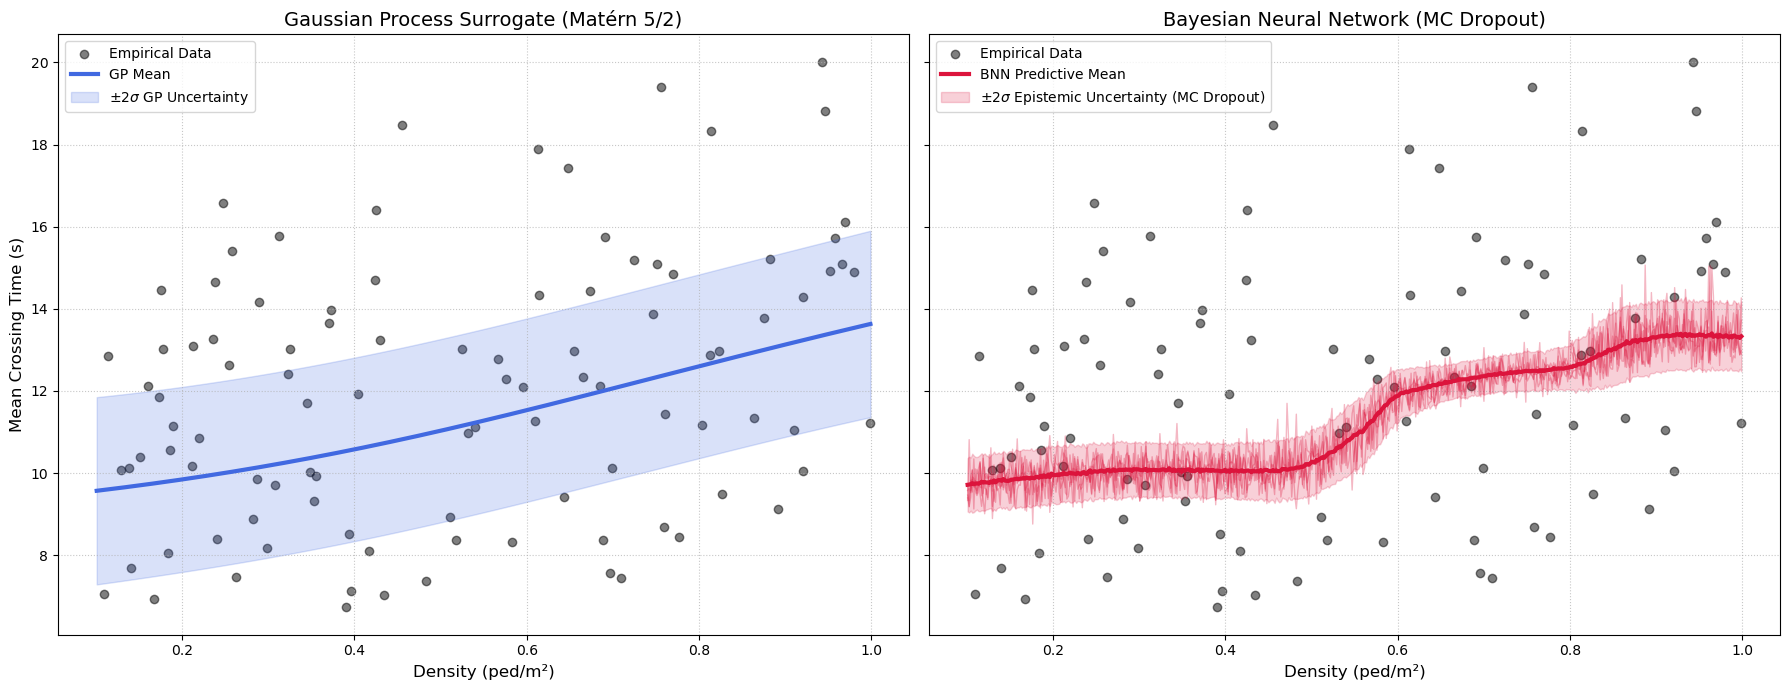

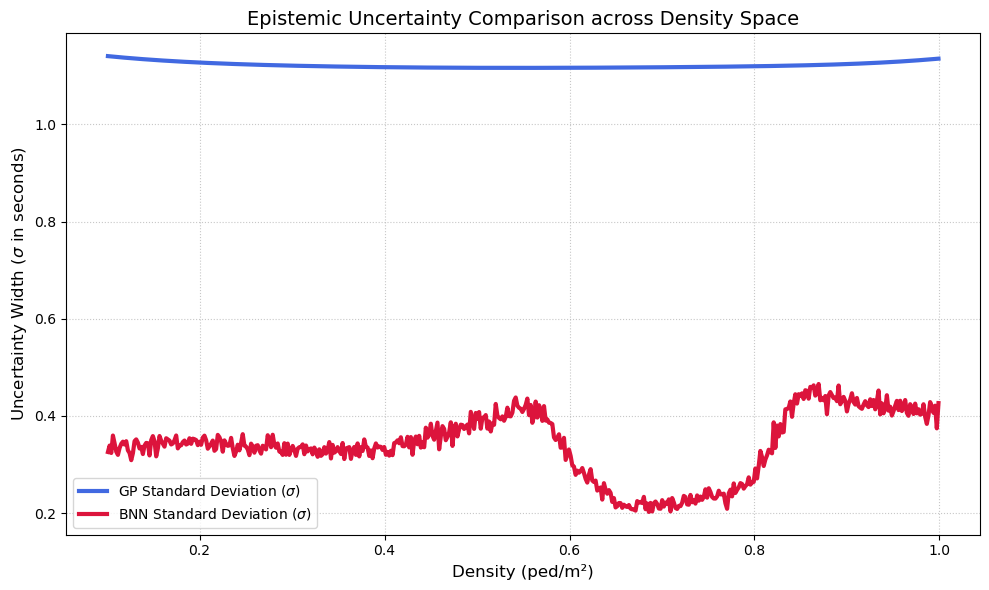

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
import torch.optim as optim
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. BAYESIAN NEURAL NETWORK ARCHITECTURE
# ==========================================
class MCDropoutBNN(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.2):
        super(MCDropoutBNN, self).__init__()
        # Standard Feedforward architecture with Dropout after hidden layers
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 1)
        
        # Dropout layer acts as our Bayesian approximator
        self.dropout = nn.Dropout(p=dropout_rate)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)          # Apply dropout
        x = self.relu(self.fc2(x))
        x = self.dropout(x)          # Apply dropout
        x = self.relu(self.fc3(x))
        x = self.dropout(x)          # Apply dropout
        return self.fc4(x)           # Linear output for regression

# ==========================================
# 2. MAIN PIPELINE
# ==========================================
def run_bnn_vs_gp_pipeline(data_path):
    print("="*60)
    print("1. LOADING DATA AND PREPROCESSING")
    print("="*60)
    
    data = np.load(data_path)
    X_raw, Y_raw = data['X'], data['Y']
    
    density_idx = 4
    target_idx = 0
    
    # Clean NaNs
    valid_mask = ~np.isnan(Y_raw[:, target_idx])
    X_clean = X_raw[valid_mask]
    y_clean = Y_raw[valid_mask, target_idx]
    
    # Train/Test Split & Sort
    X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)
    sorted_idx = np.argsort(X_test[:, density_idx])
    X_test_sorted = X_test[sorted_idx]
    y_test_sorted = y_test[sorted_idx]
    density_test = X_test_sorted[:, density_idx]

    # Scaling
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test_sorted)
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

    print("\n" + "="*60)
    print("2. TRAINING GAUSSIAN PROCESS (BASELINE)")
    print("="*60)
    kernel = ConstantKernel(1.0) * Matern(length_scale=np.ones(6), nu=2.5) + WhiteKernel(noise_level=0.1)
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=42)
    gp.fit(X_train_scaled, y_train_scaled)
    print("GP Training Complete.")

    print("\n" + "="*60)
    print("3. TRAINING BNN WITH MC DROPOUT")
    print("="*60)
    # PyTorch Setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on device: {device}")
    
    bnn = MCDropoutBNN(input_dim=6, dropout_rate=0.2).to(device)
    optimizer = optim.Adam(bnn.parameters(), lr=0.001, weight_decay=1e-4) # weight_decay acts as L2 regularization (Prior)
    criterion = nn.MSELoss()

    # Convert to Tensors
    X_train_t = torch.FloatTensor(X_train_scaled).to(device)
    y_train_t = torch.FloatTensor(y_train_scaled).unsqueeze(1).to(device)

    # Training Loop
    epochs = 10000
    bnn.train() # Set to train mode
    for epoch in range(epochs):
        optimizer.zero_grad()
        predictions = bnn(X_train_t)
        loss = criterion(predictions, y_train_t)
        loss.backward()
        optimizer.step()
        if (epoch+1) % 200 == 0:
            print(f"Epoch {epoch+1}/{epochs} | MSE Loss: {loss.item():.4f}")

    print("\n" + "="*60)
    print("4. MONTE CARLO INFERENCE & PARTIAL DEPENDENCE SWEEP")
    print("="*60)
    
    # Create the 1D Partial Dependence Sweep (Lock 5 vars, sweep Density)
    n_points = 500
    X_sweep = np.tile(np.mean(X_clean, axis=0), (n_points, 1))
    density_sweep = np.linspace(np.min(X_clean[:, density_idx]), np.max(X_clean[:, density_idx]), n_points)
    X_sweep[:, density_idx] = density_sweep
    X_sweep_scaled = scaler_X.transform(X_sweep)

    # --- GP PREDICTIONS ---
    y_gp_sweep_scaled, y_gp_cov = gp.predict(X_sweep_scaled, return_cov=True)
    y_gp_mean = scaler_y.inverse_transform(y_gp_sweep_scaled.reshape(-1, 1)).ravel()
    sigma_gp = np.sqrt(np.diag(y_gp_cov)) * scaler_y.scale_[0]

    # --- BNN MC DROPOUT PREDICTIONS ---
    X_sweep_t = torch.FloatTensor(X_sweep_scaled).to(device)
    
    # CRITICAL: Keep network in .train() mode to leave Dropout ACTIVE during inference!
    bnn.train() 
    n_mc_samples = 500
    mc_predictions = []
    
    with torch.no_grad():
        for _ in range(n_mc_samples):
            pred_scaled = bnn(X_sweep_t).cpu().numpy()
            pred_real = scaler_y.inverse_transform(pred_scaled).ravel()
            mc_predictions.append(pred_real)
            
    mc_predictions = np.array(mc_predictions) # Shape: (500 passes, 500 points)
    
    # Calculate Predictive Mean and Epistemic Uncertainty for BNN
    y_bnn_mean = mc_predictions.mean(axis=0)
    sigma_bnn = mc_predictions.std(axis=0)

    # --- TEST SET METRICS ---
    # GP
    y_gp_test_scaled, _ = gp.predict(X_test_scaled, return_std=True)
    y_gp_test = scaler_y.inverse_transform(y_gp_test_scaled.reshape(-1, 1)).ravel()
    
    # BNN
    X_test_t = torch.FloatTensor(X_test_scaled).to(device)
    bnn_test_preds = []
    with torch.no_grad():
        for _ in range(n_mc_samples):
            bnn_test_preds.append(bnn(X_test_t).cpu().numpy())
    bnn_test_preds = np.array(bnn_test_preds).mean(axis=0)
    y_bnn_test = scaler_y.inverse_transform(bnn_test_preds).ravel()

    print("\n--- PERFORMANCE COMPARISON ---")
    print(f"GP  R2: {r2_score(y_test_sorted, y_gp_test):.4f} | RMSE: {root_mean_squared_error(y_test_sorted, y_gp_test):.4f}s")
    print(f"BNN R2: {r2_score(y_test_sorted, y_bnn_test):.4f} | RMSE: {root_mean_squared_error(y_test_sorted, y_bnn_test):.4f}s")

    print("\n" + "="*60)
    print("5. GENERATING COMPARISON PLOTS")
    print("="*60)

    # ---------------------------------------------------------
    # PLOT 1: GP vs BNN Partial Dependence
    # ---------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
    
    # LEFT: Gaussian Process
    ax1.scatter(density_test, y_test_sorted, color='black', alpha=0.5, label='Empirical Data')
    ax1.plot(density_sweep, y_gp_mean, color='royalblue', lw=3, label='GP Mean')
    ax1.fill_between(density_sweep, y_gp_mean - 2*sigma_gp, y_gp_mean + 2*sigma_gp, 
                     color='royalblue', alpha=0.2, label='$\pm 2\sigma$ GP Uncertainty')
    ax1.set_title("Gaussian Process Surrogate (Matérn 5/2)", fontsize=14)
    ax1.set_xlabel("Density (ped/m²)", fontsize=12)
    ax1.set_ylabel("Mean Crossing Time (s)", fontsize=12)
    ax1.legend()
    ax1.grid(True, linestyle=':', alpha=0.7)

    # RIGHT: MC Dropout BNN
    ax2.scatter(density_test, y_test_sorted, color='black', alpha=0.5, label='Empirical Data')
    ax2.plot(density_sweep, y_bnn_mean, color='crimson', lw=3, label='BNN Predictive Mean')
    ax2.fill_between(density_sweep, y_bnn_mean - 2*sigma_bnn, y_bnn_mean + 2*sigma_bnn, 
                     color='crimson', alpha=0.2, label='$\pm 2\sigma$ Epistemic Uncertainty (MC Dropout)')
    
    # Plot a few individual MC sampled lines as "veins" to match GP leaf plot
    for i in range(5):
        ax2.plot(density_sweep, mc_predictions[i, :], color='crimson', alpha=0.3, lw=1)
        
    ax2.set_title("Bayesian Neural Network (MC Dropout)", fontsize=14)
    ax2.set_xlabel("Density (ped/m²)", fontsize=12)
    ax2.legend()
    ax2.grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.savefig("plot_5_gp_vs_bnn_surrogate.png", dpi=300)
    print("Saved: plot_5_gp_vs_bnn_surrogate.png")

    # ---------------------------------------------------------
    # PLOT 2: Uncertainty Width Comparison
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(density_sweep, sigma_gp, color='royalblue', lw=3, label='GP Standard Deviation ($\sigma$)')
    plt.plot(density_sweep, sigma_bnn, color='crimson', lw=3, label='BNN Standard Deviation ($\sigma$)')
    
    plt.title("Epistemic Uncertainty Comparison across Density Space", fontsize=14)
    plt.xlabel("Density (ped/m²)", fontsize=12)
    plt.ylabel("Uncertainty Width ($\sigma$ in seconds)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig("plot_6_uncertainty_comparison.png", dpi=300)
    print("Saved: plot_6_uncertainty_comparison.png")

if __name__ == "__main__":
    # Ensure this matches the exact location of your dataset
    DATA_PATH = r"D:\KIT\cafm_lhs_500.npz"
    run_bnn_vs_gp_pipeline(DATA_PATH)